In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import coord_transform
import simulation
import likelihood
import mcmc
from localise import ci_68_and_sigma


import os
from matplotlib.patches import Patch

In [2]:
df_short = pd.read_csv("D:\\Unimelb\\SpIRIT_In_Polar_Orbit\\mcmc\\others\\short_grb_catalogue_filter.txt",sep ='|')
df_long = pd.read_csv("D:\\Unimelb\\SpIRIT_In_Polar_Orbit\\mcmc\\others\\long_grb_catalogue_filter.txt", sep='|' )

161.33188778378715 4.057716397979432


100%|██████████| 10000/10000 [00:20<00:00, 497.90it/s]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

RA:161.33188778378715,DEC:4.057716397979432,FLUX:0.7498056
Localization completed for detection #1


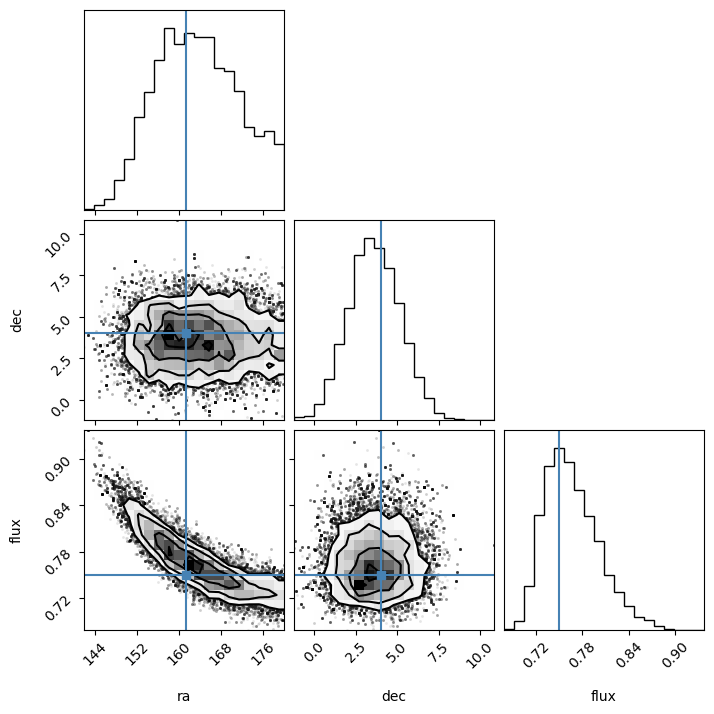

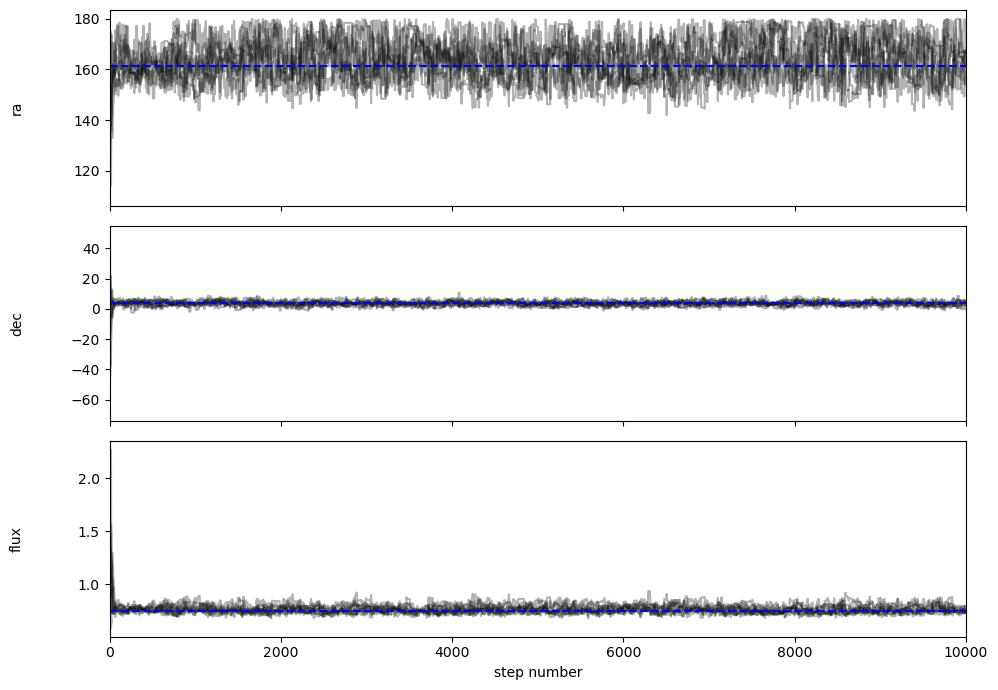

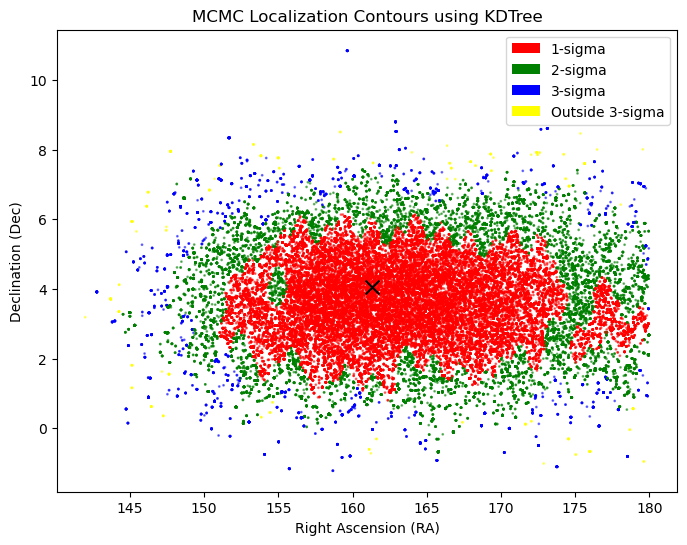

In [3]:
np.random.seed(4)
offset_angle = [5]
flux_limit = likelihood.flux_lower_bound(type ='long') # Change flux_limit for long grb = 0.463 and for short grb= 1.861
df_results_ = {}
for i, offset in enumerate(offset_angle):
    sat_pointing = simulation.sat_pointing_positions(offset)
    A = 50
    localisation_result = []
    n_det = 0
    total_generate = 0  # Counter for total GRBs generated

    minimum_num_sats_detecting_burst = 3

    while n_det < 1: # change here to set the number of detection
    
        grb_vec, ra, dec, t_90, flux_avg = simulation.generate_grb(df_long)
        
        total_generate += 1

        grb_info = {"ra": ra, 
                "dec":dec, 
                "flux_avg":flux_avg, 
                "t_90": t_90}  
    
        sat_info = {'sat_pointing': sat_pointing, 
                'flux_limit': flux_limit}

        det_result = likelihood.simulate_satellite_det(grb_vec, flux_avg, **sat_info)
    
        if sum( det_result[0] > 0 ) >=  minimum_num_sats_detecting_burst :  # Ensure it skips GRBs that do not meet conditions
        
            print(ra, dec)
            n_det += 1
            f_obs, t_obs = det_result
            #print("Detection result:", det_result)

            Ph_obs = np.array([ 0 if f < flux_limit 
                            else np.random.poisson(f * t_90 * A) for f in f_obs])  # Observed Photon count
            
            save_path = os.path.join( "./Results/l_grb_high_res_result_plots", f"offset_{offset}", f"detection_{n_det}")
            
            obs_info = {'t_obs': t_obs,
                    'f_obs': f_obs,
                    'Ph_obs': Ph_obs }
        
            mcmc_params= {'steps': 10000, 
                      'nwalk': 8, 
                      'discard': 1000,
                      'move': 2, 
                      'save_path': save_path,
                      'corner_show' : False, 'corner_save' : False, 'chain_show': False, 'chain_save' : False}
            localise_params ={'localisation_show' : False, 'localisation_save' : False
                      }
        
            flat_samples = mcmc.run_mcmc(**grb_info,
                                               **obs_info,
                                               **sat_info,
                                               **mcmc_params)
            true_value = np.array([ra, dec, flux_avg])
            ci_area_68, containment = ci_68_and_sigma(flat_samples,
                                                      true_value, 
                                                      save_path,
                                                      **localise_params)
                                                        

            print(f'RA:{ra},DEC:{dec},FLUX:{flux_avg}')
            print(f'Localization completed for detection #{n_det}')    
        
            localisation_result.append([ra, dec, t_90, flux_avg, f_obs, ci_area_68, containment, total_generate])

        df_results_[i] = pd.DataFrame(localisation_result, columns=['RA', 'Dec', 'T90', 'Flux_Avg', 'fcos', 'CI_Area_68', 'containment','Total generated'])
    
#df_results_[i].to_csv(f'./Results//l_grb_high_res_result_plots/long_{offset}.csv', index=False)
#print(f'Total GRBs generated: {total_generate}, Total detected: {n_det}')

In [4]:
# 1. Simulate bursts uniformly on the sky until we get a detection
# 2. Set limits on how much of the sky to search based on pointing of detected satellites
# 3. Run MCMC on the determined patch of sky

In [59]:
from time_delay_flux_guess import fibonacci_sphere, euclidean_distance

num_vertices = 41253
# Generate grid from Fibonacci sphere
mesh = fibonacci_sphere(num_vertices)
grid_ra = np.degrees(np.arctan2(mesh[:, 1], mesh[:, 0])) + 180
grid_dec = np.degrees(np.arcsin(mesh[:, 2]))


num_grid_points = len(grid_ra)
ra_mcmc = flat_samples[:, 0]
dec_mcmc = flat_samples[:, 1]
limit = len(flat_samples)

# Assign each sample to the closest grid point
nearest_grid_indices = np.zeros(len(flat_samples), dtype=int)
grid_occupancy = np.zeros_like(grid_ra)
for i, (ra, dec) in enumerate(zip(ra_mcmc, dec_mcmc)):
    distances = euclidean_distance(ra, grid_ra, dec, grid_dec)
    closest_grid_point_index = np.argmin(distances)
    nearest_grid_indices[i] = closest_grid_point_index
    grid_occupancy[closest_grid_point_index] = grid_occupancy[closest_grid_point_index] + 1






# plt.figure(figsize = (3.6*3, 1.8*3))

# # # newColours = np.zeros_like(grid_occupancy)

# # plt.xlim(180, 220)
# # plt.ylim(-25, 5)
# # # nPoints = sum(grid_occupancy)



# plt.scatter(grid_ra, grid_dec, s = 150, c = sigmas)
# plt.xlim(125, 180)
# plt.ylim(0, 25)
# plt.colorbar()
# plt.show()



# # Count occurrences per grid point
# grid_counts = np.bincount(nearest_grid_indices, minlength=num_grid_points)
# sorted_counts = np.sort(grid_counts)[::-1]
# cumulative_points = np.cumsum(sorted_counts)


# # Find the grid points corresponding to the sigma limits
# sigma_1_index = np.searchsorted(cumulative_points, 0.68 * limit)
# sigma_2_index = np.searchsorted(cumulative_points, 0.95 * limit)
# sigma_3_index = np.searchsorted(cumulative_points, 0.997 * limit)


# credible_interval_68 = (sigma_1_index + 1)  # Approximate area covered


In [76]:

sigmas = np.zeros_like(grid_occupancy)

trials = len(flat_samples)
total_prob_consumed = 0
total = trials
normalised_grid_occupancy = grid_occupancy / total

for j in range(trials):

    largest_value_index = np.argmax(normalised_grid_occupancy)
    prob = normalised_grid_occupancy[largest_value_index]
    normalised_grid_occupancy[largest_value_index] = 0
    total_prob_consumed += prob

    if total_prob_consumed < 0.68:
        sigmas[largest_value_index] = 1
    elif (total_prob_consumed > 0.68) and (total_prob_consumed < 0.95):
        sigmas[largest_value_index] = 2
    else:
        sigmas[largest_value_index] = 3


print(set(sigmas))

# # newColours = np.zeros_like(grid_occupancy)

# plt.xlim(180, 220)
# plt.ylim(-25, 5)
# # nPoints = sum(grid_occupancy)




{0.0, 1.0, 2.0, 3.0}


<Figure size 1080x540 with 0 Axes>

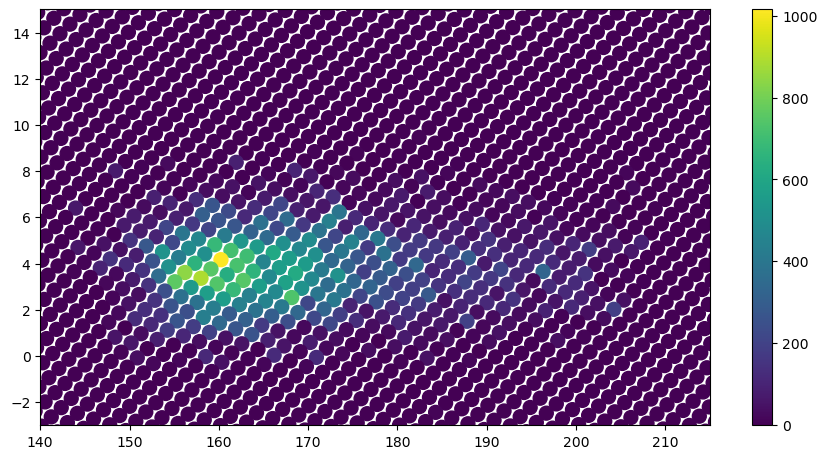

In [80]:

plt.figure(figsize = (3.6*3, 1.8*3))

plt.figure(figsize = (3.6*3, 1.8*3))
plt.scatter(grid_ra, grid_dec, s = 100, c = grid_occupancy)
plt.xlim(140, 215)
plt.ylim(-3, 15)
plt.colorbar()
plt.show()

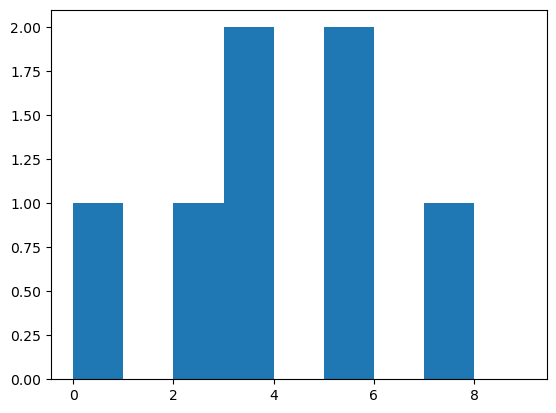

In [79]:
plt.hist( np.random.uniform(0, 10, 10), bins = np.arange(0, 10, 1))
plt.show()

